# Gaussian Regression Understanding from the Basis 
In this notebook we aim at developing your understanding of the Gaussian Process Regression from the grounds of a simple Gaussian distribution.
**Learning Outcomes**
1. Develop a comprehension of moving from Gaussian Distribution to Gaussian Process
2. Develop understanding of effect of a kernel in specifying the function prior
3. Develop understanding of sampling a function in multi-dimensional settings


In [4]:
%matplotlib inline

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

# Bivariate Gaussian
The Gaussian distribution is the backbone of the Gaussian Processes. Therefore, we start by reviewing some of its behaviour with respect to the input space variances. However, we start directly from a bivariate Gaussian to get an intuition of how a Gaussian behaves with respect to its covariance matrix. This helps our understanding of the development of a Gaussian Processes. Note that this is a refresher and is not meant to be an exhaustive review of the Gaussian distribution.


## var(x)= var(y)

[[1, 0], [0, 1]]


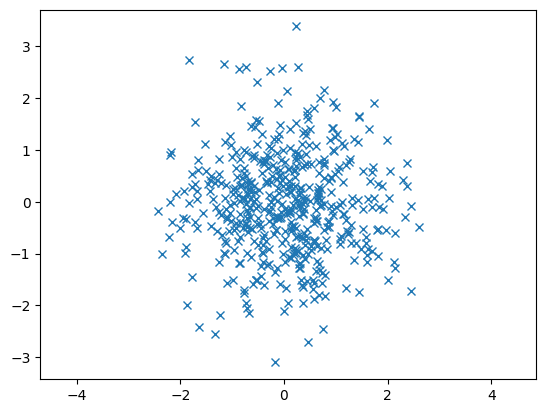

In [9]:
μ = [0, 0]
Σ = [[1, 0], [0, 1]] 
x, y = np.random.multivariate_normal(μ, Σ, 500).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show
plt.savefig("figures\GaussianSamplesSpherical.jpg")
print(Σ)

We can realise that the data is centered on a circle-like shape because var(x)=var(y)

## var(x) < var(y)

[[1, 0], [0, 10]]


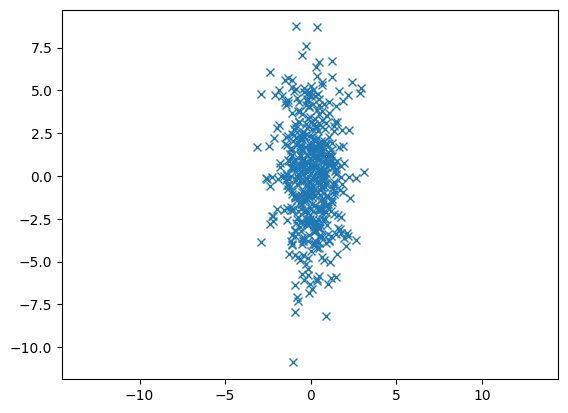

In [10]:
μ = [0, 0]
Σ = [[1, 0], [0, 10]]
x, y = np.random.multivariate_normal(μ, Σ, 500).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show
plt.savefig("figures\GaussianSamplesVertical.jpg")
print(Σ)

Here we can see that the data has a vertical shape because the variance of y is higher than the variance of x, so we see more spread on the y axis than on x axis.

In [11]:
print('var(x)=', Σ[0][0])
print('var(y)=', Σ[1][1])

var(x)= 1
var(y)= 10


## var(x) > var(y)

[[10, 0], [0, 1]]


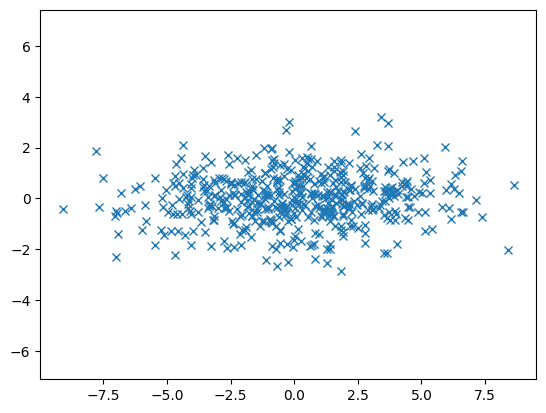

In [12]:
μ = [0, 0]
Σ = [[10, 0], [0, 1]] 
x, y = np.random.multivariate_normal(μ, Σ, 500).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show
plt.savefig("figures\GaussianSamplesHorizontal.jpg")
print(Σ)

In [13]:
print('var(x)=', Σ[0][0])
print('var(y)=', Σ[1][1])

var(x)= 10
var(y)= 1


Note that in both of the above cases there is no covariance between x and y: covar(x,y)= 0 (covariance is a symmetrical relationship: covar(x,y)= covar(y,x))

In [14]:
print('covar(x,y)=', Σ[0][1])
print('covar(y,x)=', Σ[1][0])

covar(x,y)= 0
covar(y,x)= 0


## var(x)=var(y) with cov(x,y) > 0

[[1, 0.9], [0.9, 1]]


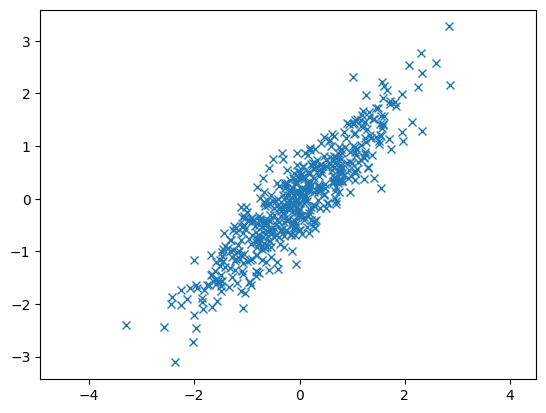

In [15]:
μ = [0, 0]
Σ = [[1, 0.9], [0.9, 1]] 
x, y = np.random.multivariate_normal(μ, Σ, 500).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show
plt.savefig("figures\GaussianSamplesDiagonal+.jpg")
print(Σ)

we can see that when we introduced covariance between x and y the data took an inclined line shape (not a vertical or horizontal).

## var(x)=var(y) with cov(x,y) < 0

[[1, -0.9], [-0.9, 1]]


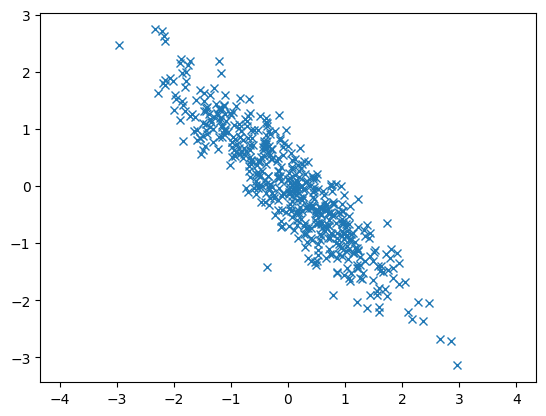

In [16]:
μ = [0, 0]
Σ = [[1, -0.9], [-0.9, 1]] 
x, y = np.random.multivariate_normal(μ, Σ, 500).T
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show
plt.savefig("figures\GaussianSamplesDiagonal-.jpg")
print(Σ)

Ok, now we refreshed our memory on the effect of the variance and covariance of a Bivariate Gaussian distribution with respect to data generation, we can move to a Multivariate Gaussian. 

# Multivariate Gaussian to Gaussian Processes

We generate a set of 3 d points from a simple Gaussian that lives in the 3 dimensional space. Again the covariance matrix plays an important role. Here we have chosen a covariance matrix Σ that decreases when we move along its diagonal horizontally, left to right (since the matrix is symmetrical we look only at the upper or lower diagonal matrix). We call such a matrix monotonic.

In [51]:
# Creating a 'half' covariance matrix (taking advantage of the
# fact that it is symmetrical - we will mirror it later)

Σ_ = np.matrix([[1, .5, .1], [0, 1, .5], [0, 0, 1]])
print(Σ_)

[[1.  0.5 0.1]
 [0.  1.  0.5]
 [0.  0.  1. ]]


Now to formulate a covariance matrix we can perfrom the follwoing operation

In [52]:
I = np.eye(3)  # Create an identity matrix of M dimensions
Σ = Σ_ + Σ_.T - I # Flipping the covariance matrix and removing the double-up of the diagonal
print(Σ)

[[1.  0.5 0.1]
 [0.5 1.  0.5]
 [0.1 0.5 1. ]]


Ok now let us plot the different dimensions agsint each other

[[1.  0.5 0.1]
 [0.5 1.  0.5]
 [0.1 0.5 1. ]]


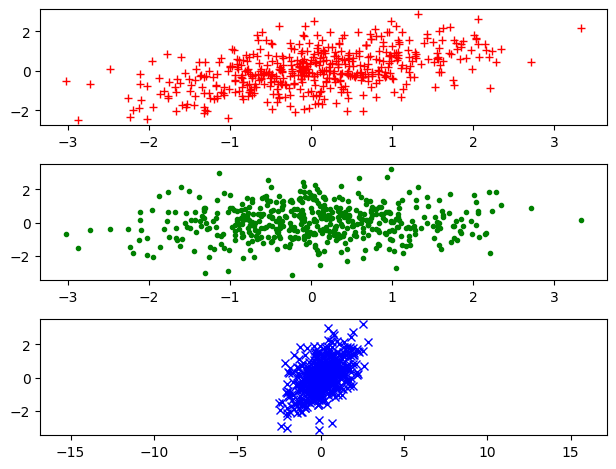

In [53]:
μ = np.zeros(3) # Initialising a 3x3 matrix to store the means
#Σ = np.matrix([[1, .5, .1], [.5, 1, 0.5], [.1, 0.5, 1]])
print(Σ)
x, y, z = np.random.multivariate_normal(μ, Σ, 500).T # Getting three dimensional datapoints for this "3-ary" multivariate gaussian
fig, axs = plt.subplots(3)
axs[0].plot(x, y, '+r')  # plotting x vs y
axs[1].plot(x, z, '.g')  # plotting x vs z
axs[2].plot(y, z, 'xb')  # plotting y vs z
plt.axis('equal')
plt.show

plt.tight_layout()
plt.savefig("figures/GaussianMultivariateSamples.jpg")

## Turning a Gaussian Covariance Matrix from a Multi-dim Data Generator into a One-dim Sequence Generator
In the previous sections we generated lots of data around the mean of a Gaussian and used the covariance as the probability according to which an individual data point is shifted away from the mean. The dimension of the covariance dictated the dimension of each individual point.

Now we are going to move to a new concept where the dimension of the covariance matrix (the Gaussian) dictates *the number* of data points that will be generated. Each multi-dim data point that is generated cording to the covariance matrix represents a sequence; where the x axis is simply the index of the dimension (each dimension generates a data point), while the y axis is given by the value of each dimension of the generated data point. Hence, the resultant sequence coming from a data point lives in a 2 d dimensional space. This concepts revolutionise the way we look at a Gaussian.

So for example if the Gaussian is a 3 d multivariate then we are able to generate a series of 3 points, if the Gaussian has 10d multivariate then we are able to generate 10 data points sequence. We can generate lots of those sequences where each time the covariance inner characteristics dictates the shape of the sequence.


## Sampling form a 3 d Gaussian to obtain 3 output values y1, y2 , y3

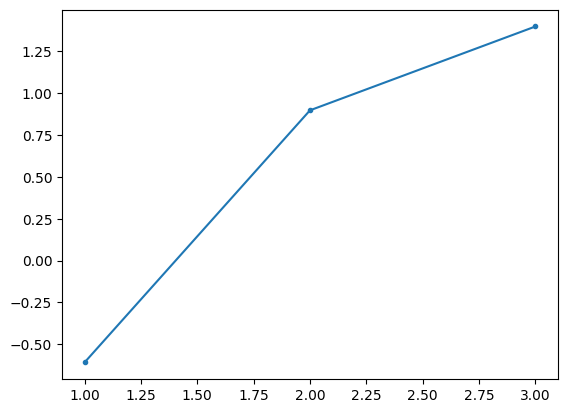

In [54]:
y1, y2, y3 = np.random.multivariate_normal(μ, Σ, 1).T  # Using mu and Sigma from prior cells to find a single datapoint
plt.plot([1,2,3],[y1, y2, y3],'.-')
plt.savefig("figures\GP3points.jpg")

## Generate more data and animate it

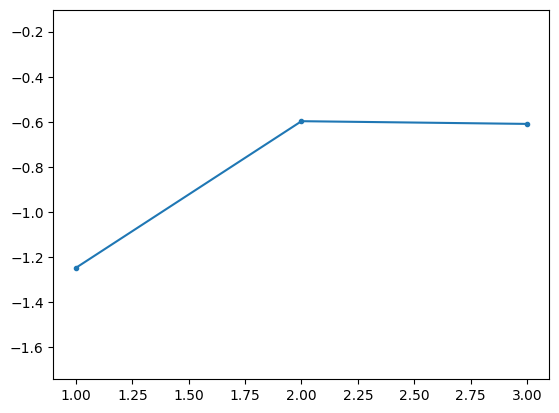

[[1.  0.5 0.1]
 [0.5 1.  0.5]
 [0.1 0.5 1. ]]


In [55]:
n = 6
for i in range(n):
    y1, y2, y3 = np.random.multivariate_normal(μ, Σ, 1).T
    plt.plot([1,2,3],[y1, y2, y3],'.-')
    plt.axis('equal')
    clear_output(wait=True)
    plt.show()
    time.sleep(.2)
print(Σ)

## Higher order Gaussian
Now let's experiment with a higher order Gaussian, ex. a Gaussian with 10 d. As we said earlier we can generate 10 data points from such a Gaussian. 

In [56]:
d = 10 # covariance matrix dimension 
 #which corresponds to the number of data points that we will sample for the Gaussian Process 
μ = np.zeros(d)
I = np.eye(d)
Σ = np.eye(d) # do not assign I= Σ  as this is by assigning reference
for i in range(d): 
    for j in range(i+1,d):
        Σ[i,j] = Σ[i,j-1]- 1/d
Σ = Σ + Σ.T - I
print(Σ)

[[1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1]
 [0.9 1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2]
 [0.8 0.9 1.  0.9 0.8 0.7 0.6 0.5 0.4 0.3]
 [0.7 0.8 0.9 1.  0.9 0.8 0.7 0.6 0.5 0.4]
 [0.6 0.7 0.8 0.9 1.  0.9 0.8 0.7 0.6 0.5]
 [0.5 0.6 0.7 0.8 0.9 1.  0.9 0.8 0.7 0.6]
 [0.4 0.5 0.6 0.7 0.8 0.9 1.  0.9 0.8 0.7]
 [0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  0.9 0.8]
 [0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  0.9]
 [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]]


Now let us visualise the shape of an example of the generated data points.

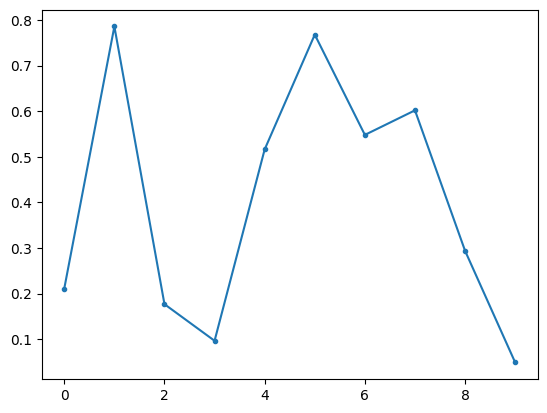

In [57]:
y = np.random.multivariate_normal(μ, Σ, 1).T
x = np.arange(d)
plt.plot(x,y, '.-')
plt.savefig("figures\GP10Points.jpg")

Now we will develop helper functions to help us visualise the data. The main deature of this view of a multi-variate Gaussian is that the sequences are wiggling according to the covariance matrix.

In [58]:
def animate_samples(x, y):
    for i in range(n):
        plt.plot(x,y[i])
        clear_output(wait=True)
        plt.show()
        time.sleep(.2)

def plot_samples(x, y):
    #print(y.shape)
    n = y.shape[0]
    for i in range(n): plt.plot(x,y[i])
    #plt.savefig("figures\GP50Pints.jpg")
    plt.show()

Now we will use the above functions to generate a sequence of 10 data points. The shape of the sequence is dictated by the covariance matrix. We will see few examples later. Here we use a monotone covariance matrix that gives a covariance that increase with the index.

In [59]:
def montone_covar(d=10):   # d is covariance matrix dimension which corresponds to the number
                           # of data points that we will sample for the Gaussian Process 
    μ = np.zeros(d)
    I = np.eye(d)
    Σ = np.eye(d) # do not assign I = Σ  as this is by assigning reference
    for i in range(d): 
        for j in range(i+1,d):
            Σ[i,j] = Σ[i,j-1]- 1/d
    Σ = Σ + Σ.T - I  # takes advantage of symmetry
    return Σ, μ

Ok we are ready to generate the sequences(functions).

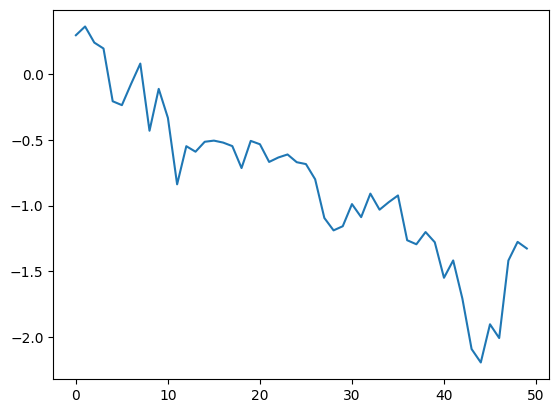

[[1.   0.98 0.96 ... 0.06 0.04 0.02]
 [0.98 1.   0.98 ... 0.08 0.06 0.04]
 [0.96 0.98 1.   ... 0.1  0.08 0.06]
 ...
 [0.06 0.08 0.1  ... 1.   0.98 0.96]
 [0.04 0.06 0.08 ... 0.98 1.   0.98]
 [0.02 0.04 0.06 ... 0.96 0.98 1.  ]]


In [61]:
d = 50 # dim of the Gaussian which correspends to number of data points
n = 6  # number of functions that we want to sample
Σ, μ = montone_covar(d)
y = np.random.multivariate_normal(μ, Σ, n) 
x = np.arange(d)
animate_samples(x, y)
print(Σ)

Let us now plot all of these sequences that we have already generated

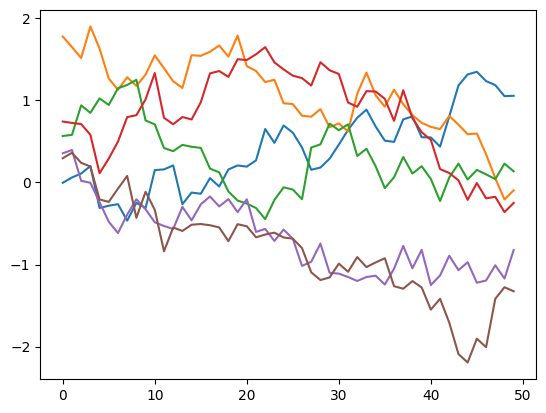

In [62]:
plot_samples(x, y)


## Generalising the Sequence Generation mechanism using a helper function

Let us define a useful function and add a slop to the line via the mean

In [67]:
def function_samples_discrete_x(μ, Σ, n=6):
    d = len(μ)
    y = np.random.multivariate_normal(μ, Σ, n) 
    x = np.arange(d)
    animate_samples(x, y)
    plot_samples(x, y)
    

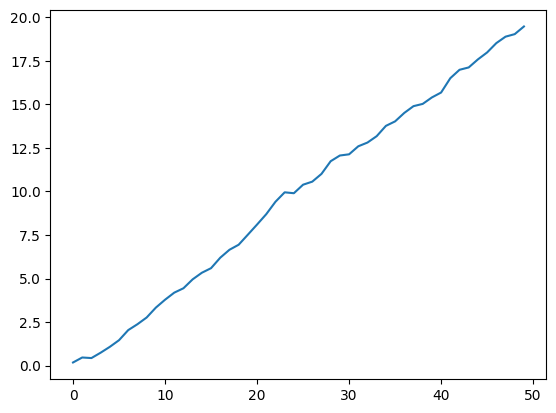

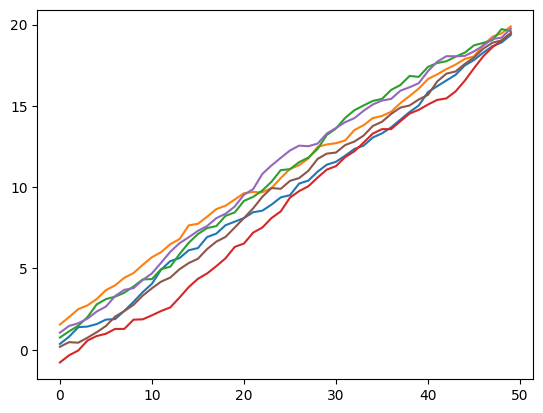

In [68]:
d = 50
Σ, μ = montone_covar(d)
#print(n)
#print(μ.shape)
for i in range(d): μ[i] = μ[i-1] + 0.4
function_samples_discrete_x(μ, Σ, n)

As we can see, a monotone covariance generates a straight line shape sequence. Let us move into a more complex sequences.

## Generating a Periodic Sequence (function) via a Gaussian

Let us draw a periodic function via the Gaussian!
To do so we will use the mechanism of radial basis functions that we are familiar with. In other words we will create a Gaussian that has a covariance matrix that has RBF elements. When we use such a matrix to generate the sequence it will generate a periodic like sequence shape.

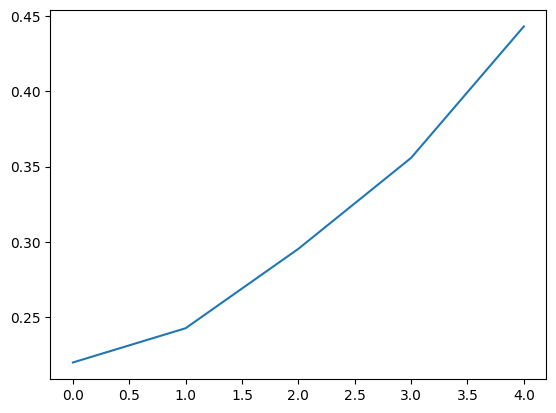

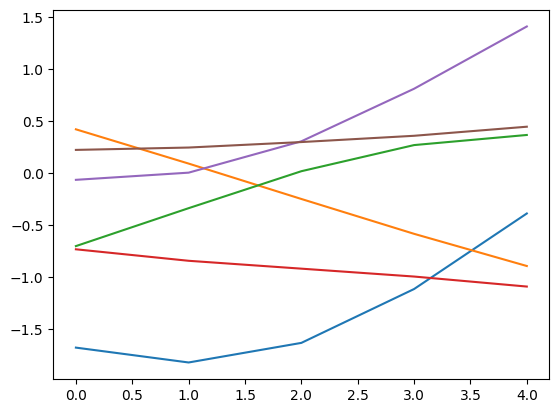

[[1.         0.96078944 0.85214379 0.69767633 0.52729242]
 [0.96078944 1.         0.96078944 0.85214379 0.69767633]
 [0.85214379 0.96078944 1.         0.96078944 0.85214379]
 [0.69767633 0.85214379 0.96078944 1.         0.96078944]
 [0.52729242 0.69767633 0.85214379 0.96078944 1.        ]]


In [69]:
def rbf_covar(d=5, σ=5): 
    # d is covariance matrix dimension which corresponds to the number of data points 
    # that we want to sample from the Gaussian Process 
    μ, Σ, I = np.zeros(d), np.eye(d), np.eye(d)# do not assign I= Σ  as this is assigning by reference
    for i in range(d): 
        for j in range(i+1,d):
            Σ[i,j] = np.exp(-((i-j)**2)/σ**2)
    Σ = Σ + Σ.T - I
    return Σ, μ

Σ, μ = rbf_covar()
function_samples_discrete_x(μ, Σ, n)
print(Σ)


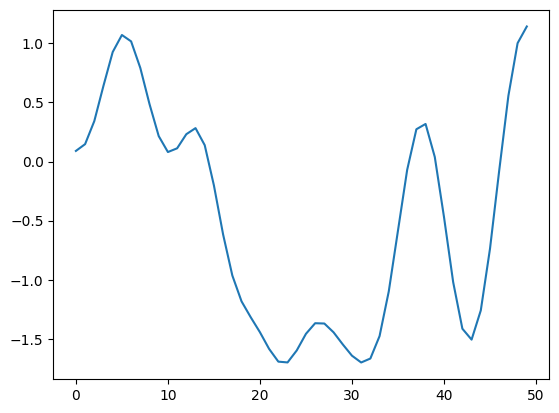

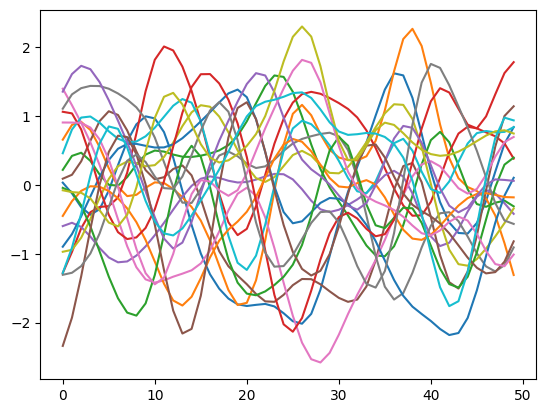

[[1.00000000e+00 9.60789439e-01 8.52143789e-01 ... 4.22415241e-39
  9.44975498e-41 1.95145238e-42]
 [9.60789439e-01 1.00000000e+00 9.60789439e-01 ... 1.74307090e-37
  4.22415241e-39 9.44975498e-41]
 [8.52143789e-01 9.60789439e-01 1.00000000e+00 ... 6.63967720e-36
  1.74307090e-37 4.22415241e-39]
 ...
 [4.22415241e-39 1.74307090e-37 6.63967720e-36 ... 1.00000000e+00
  9.60789439e-01 8.52143789e-01]
 [9.44975498e-41 4.22415241e-39 1.74307090e-37 ... 9.60789439e-01
  1.00000000e+00 9.60789439e-01]
 [1.95145238e-42 9.44975498e-41 4.22415241e-39 ... 8.52143789e-01
  9.60789439e-01 1.00000000e+00]]


In [71]:
d = 50
Σ,μ = rbf_covar(d=d, σ=5)
function_samples_discrete_x(μ, Σ, n=20)
print(Σ)

In the above, you might have already realised that generating a sequence, is a first step towards coming up with a mechanism to deal with regression. After all, if we are able to generate any type of sequence or a function, then we can build a model that can predict the value of a data point given a set of other data points sequence (a dataset), we simply use the Bayesian rules for that. But before we are able to do so, an important question remains in order to be able to fully deal with regression, what if we want to generate an infinite number of data points? I.e. instead of a finite sequence of data points what if we wanted to generate a continuous function. In the next section we attempt to answer this question.

# Gaussian Processes Priors: Matrix to Kernels
## From a Discrete Covariance Matrix to a Continuous Kernels


In all of the above we assumed that our model has one input $i$ that is integer and we sampled $i$ from $f(i)$ to get $f(i)$ where each sample $(f(0), f(1),...,f(d-1))$ has a Gaussian distribution.


Now we will move to continuous cases where we define the covariance in terms of a kernel function instead of a matrix and then we sample any arbitrary $x$'s that are not necessarily integers and we get their $f(x)$ and we plot them. So our input next is going to $x_i$ to get $f(x_i)$ where each sample $(f(x_1), f(x_2),...,f(x_d))$ has a Gaussian distribution.



The notebook is structured in a way to make the concept of moving from the number of samples d (that corresponds with the dimension of the covariance) to a number of integers inputs 0...d (then to any real input x), visible. From an implementation perspective, however, the difference is subtle and may seem trivial. The take away is that GP specifically uses the covariance kernel to model (or plot we may say) any arbitrary function. The input values themselves is less important, what is more important is the distances between them and how the kernel measures these distances in a way that create a specific behaviour (straight line, periodic function etc.)


## The Prior
We will show the GP prior, which plays an essential role in specifying the nature and pre-assumptions of the modeled function. In particular, the kernel plays the role of the feature mapping in paramteric models. We will see late, however that GP  gives more flexibility and streamline the prcocess of finding optimal values for the kernel hyper paramters.

## Constructing the covariance matrix efficiently

In the following efficient method we take advantage of broadcasting: $x-x_i$ is vector-element which force subtracting rach element in $x$ to be subtracted from current element $x_i$.

In [72]:
σ = 5
x = np.linspace(0,5,num=4)
d = len(x)
print(x)
#start = time.time()
Σ = np.eye(d)
for i, xi in enumerate(x):
    Σ[i] = np.exp(-((x-xi)**2)/σ**2) 
#print('method4', time.time() - start)
print(Σ)

[0.         1.66666667 3.33333333 5.        ]
[[1.         0.89483932 0.64118039 0.36787944]
 [0.89483932 1.         0.89483932 0.64118039]
 [0.64118039 0.89483932 1.         0.89483932]
 [0.36787944 0.64118039 0.89483932 1.        ]]


There is a very slight rounding error that is occuring due to broadcasting. 
Also note that there is plenty of ways to construct such a matrix, we provide some in a separate exercise.

Ok, now we can use this method in a function 

In [73]:
def rbf_kernel(x, σ=5, h1=1, h2=0, h3=0): 
    # h1, h2, h3 are hyperparameters that determine the shape of the prior function
    # x is a real vector of an arbitrary size
    d = len(x)
    μ, Σ = np.zeros(d), np.eye(d)
    
    # efficient; takes advantage of broadcasting: x-xi is vector-element
    for i, xi in enumerate(x):
        Σ[i] = np.exp(-((x-xi)**2)/σ**2) 
        
    Σ = h1*Σ + h2*x.T*xi + h3  # play with h1, h2, h3 to see the effect
    
    return Σ, μ

In [74]:
# n is number of functions to be sampled
# continuous x, can take any arbitrary number of samples
def function_samples(μ, Σ, n=6):  
    d = len(μ)
    y = np.random.multivariate_normal(μ, Σ, n) 
    x = np.linspace(0,50,num=d)
    animate_samples(x, y)
    plot_samples(x, y)

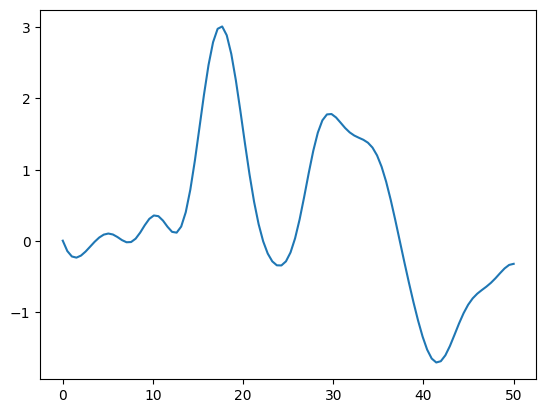

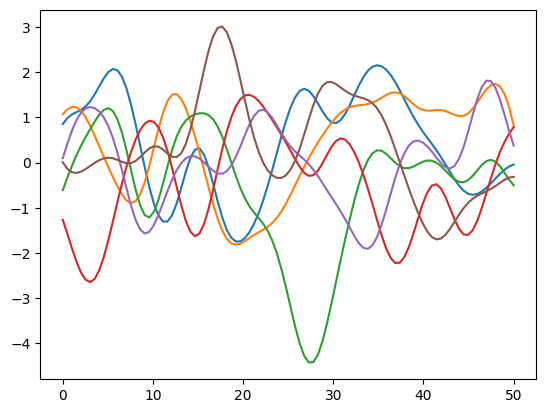

[[1.00000000e+00 9.84184154e-01 9.38221701e-01 ... 7.17052194e-66
  3.20215697e-67 1.38511937e-68]
 [9.84184154e-01 1.00000000e+00 9.84184154e-01 ... 1.55529100e-64
  7.17052194e-66 3.20215697e-67]
 [9.38221701e-01 9.84184154e-01 1.00000000e+00 ... 3.26757288e-63
  1.55529100e-64 7.17052194e-66]
 ...
 [7.17052194e-66 1.55529100e-64 3.26757288e-63 ... 1.00000000e+00
  9.84184154e-01 9.38221701e-01]
 [3.20215697e-67 7.17052194e-66 1.55529100e-64 ... 9.84184154e-01
  1.00000000e+00 9.84184154e-01]
 [1.38511937e-68 3.20215697e-67 7.17052194e-66 ... 9.38221701e-01
  9.84184154e-01 1.00000000e+00]]


In [75]:
x = np.linspace(0,50,num=100)
Σ, μ = rbf_kernel(x, σ=4)
function_samples(μ, Σ)
print(Σ)

Let us see the effect of the second argument a2

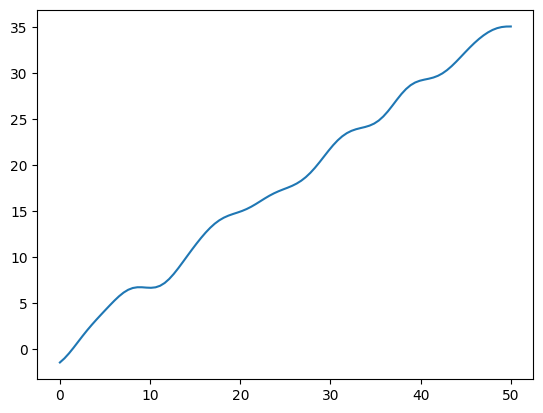

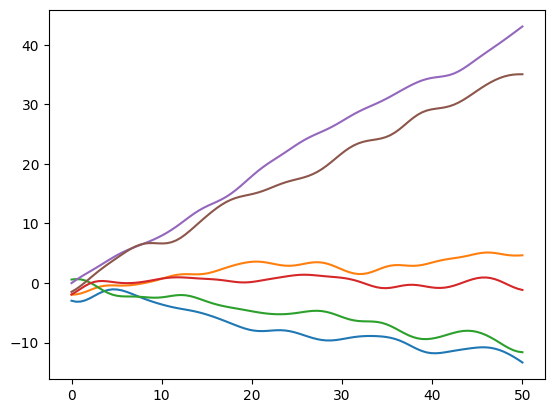

In [83]:
x = np.linspace(0,50,num=100)
Σ, μ = rbf_kernel(x, σ=4, h1=1,h2=.1,h3=0)
#Σ, μ = rbf_kernel(x, σ=4, h1=1,h2= 1,h3=0)  # uncomment to see the effect
#Σ, μ = rbf_kernel(x, σ=4, h1=1,h2=100,h3=0) # uncomment to see the effect
function_samples(μ, Σ)

As h2 gets larger, it 'straightens' out the plots, which dampens the impact of the Gaussian.
This makes sense if we look at the covariance function definition.

h3 seems to shift the values 'vertically'

# GP for Regression

In the previous section we saw how to construct the prior via the kernel. Now we turn our attention to conducting regression. Our goal is to predict the output value of an input by using the values of the known input-output pair to us (training).

Our goal is to predict $t_{N+1}$ given the dataset  $\boldsymbol{t}_N$. 

Where we have $\boldsymbol{t}_N=\begin{bmatrix}
t_1\\
\vdots\\
t_N
\end{bmatrix}$.

In other words, we want to evaluate the probability $p(t_{N+1}|\boldsymbol{t}_N)$.

Our specification is that we have: $t_n = y_n + \epsilon_n$,  where $y$ represents our data model.

If we consider a Gaussian noise distributed over the data model to produce the observed data, then the expected *mean* of any observed data point $t_n$ is $y_n$ and the *variance* of it is $\sigma=\beta^{-1}$.

$p(t_n|y_n) = \mathcal{N}(t_n|y_n,\beta^{-1})$

The joint distribution of all the observed target values conditioned on the values is 
$p(\boldsymbol{t}_N|\boldsymbol{y}_N) = \mathcal{N}(\boldsymbol{t}_N|\boldsymbol{y}_N, \beta^{-1} \boldsymbol{I}_N)$

Because we are dealing with a Gaussian process, by definition the marginal distribution of the data model $\boldsymbol{y}$ is given by a Gaussian whose mean is zero and whose covariance is defined by a kernel $\boldsymbol{K}$, so that $p(\boldsymbol{y})=\mathcal{N}(\boldsymbol{y}| \boldsymbol{0}, \boldsymbol{K})$.

Hence, the joint distribution over $t_1,..., t_{N+1}$ will be given by
$p(\boldsymbol{t}_{N+1}) = \mathcal{N}(\boldsymbol{t}_{N+1} | \boldsymbol{0}, \boldsymbol{C}_{N+1})$
where $\boldsymbol{C}_{N+1}$ is a covariance matrix that is a combination of a kernel and additive Gaussian noise. Because this joint distribution is Gaussian, we can partition the covariance matrix as 

$\boldsymbol{C}_{N+1} = \begin{pmatrix}
\boldsymbol{C}_N & \boldsymbol{k}\\
\boldsymbol{k}^T & c
\end{pmatrix}$
where the vector $\boldsymbol{k}$ has elements $k(x_n,x_{N+1})$ for n=1,...,N, and the scalar $c=k(x_{N+1}, x_{N+1})  + \beta^{-1}$. 

By using well know results for the conditional distribution we can conclude that the $t_{N+1}|\boldsymbol{t}$ has a Gaussian distribution with mean and covariance as follows:

$m(x_{N+1}) = \boldsymbol{k}^{T} \boldsymbol{C}^{-1}_{N} \boldsymbol{t}$

$\sigma^2(x_{N+1}) = c - \boldsymbol{k}^{T} \boldsymbol{C}^{-1}_{N} \boldsymbol{k}$

In [85]:
def generate_y(x):
    n = x.shape[0]
    
    # now we generate data... 
    #y = np.random.multivariate_normal(μ_y, Σ_y) # from a multivariate Gaussian
    #y = x*np.sin(x)                              # from a sinusoidal function
    y = np.cos(x)
    return y

def add_noise(y,σ_ε):
    # we add a Gaussian noise to the mapping 
    ε = np.random.normal(0, σ_ε, n)

    # now we construct the target data t
    # where we assume that the each data point has noise independent from other data points
    t = (y + ε).reshape(n,1)
    
    return t

def constructFit_GP(x, σ_y, h1, h2=0, h3=0):
    n = x.shape[0]
    
    # we construct a multivariate periodic kernel
    Σ_y, μ_y = rbf_kernel(x, σ=σ_y, h1=h1, h2=h2, h3=h3)

    # the covariance of t is simply = the covariance of y + the covariance of the noise ε
    # the covariance of the isotropic noise ε is σ2*I
    #Σ_t = Σ_y + (σ_ε**2)*np.eye(n)
    Σ_t = Σ_y + (.1**2)*np.eye(n)
    
    Σ_t_1 = np.matrix(np.linalg.inv(Σ_t)) #inverse the covariance kernel
    
    return  Σ_t_1 #, Σ_t

def predict_GP(xi, x, σ_y, Σ_t_1):
    # we want to predict yi of xi
    #xi = 1.4*π
    #xi = np.random.rand()*wv*π

    # now we apply the regression formula for the μ and σ of an unknown point
    k  =  np.exp(-((x -xi)**2)/σ_y**2).reshape(n,1) 
    c  =  np.exp(-((xi-xi)**2)/σ_y**2) + σ_ε**2

    # per the definition found in my notes: "Gaussian Process for Regression and Classification"
    μ_ti  =    k.T*Σ_t_1*t
    σ2_ti = c- k.T*Σ_t_1*k
    σ_ti = np.sqrt(np.abs(σ2_ti))
    
    return μ_ti, σ_ti


we plot the prediction for a random 5 points along with upper and lower range (2 standard deviation)

49.79282696049789


C:\Users\wesle\AppData\Local\Temp\ipykernel_14860\2394818499.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  μ_t[i], σ_t[i] = predict_GP(x_[i], x, σ_y, Σ_t_1)


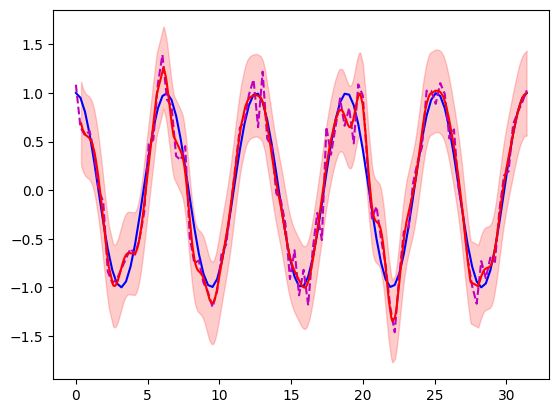

In [89]:
π  = np.pi  # for convenience

# Data hyper parameter
wv = 5      # roughly how many waves 
n  = 100    # number of data points #  change this to see the effect
x  = np.linspace(0, wv*2*π, n)
σ_ε = 0.2 #.08  #  determine the amount of noise

# generate the data and noise to it
y = generate_y(x)
t = add_noise(y,σ_ε)

# models hyper paramteres
σ_y =  1  #  determine the function's shape
h1  =  1  #  determine the function's shape
h2  =  0  #  determine the function's shape
h3  =  0  #  determine the function's shape

# now construct the GP model

Σ_t_1 = constructFit_GP(x, σ_y=σ_y,  h1=h1, h2=h2, h3=h3)
print(Σ_t_1[25,25] )
plt.plot(x, y, 'b-')
plt.plot(x, t, 'm--')

# we plot the prediction for m random points along +- 2std deviation
m = 500            # how many points to be predicted, change this to see the effect

# these are the random points that we want to predict thier ys
edg = 1
x_ = (np.sort(np.random.rand(m+edg*2))*wv*2*π).reshape((m+edg*2,))
x_ =x_[edg:-edg] 

μ_t = np.zeros(m)  # this will hold the predicted targets
σ_t = np.zeros(m)  # this will hold the confidence in the predictions
for i in range(m):
    μ_t[i], σ_t[i] = predict_GP(x_[i], x, σ_y, Σ_t_1)

plt.fill_between(x_, μ_t-2*σ_t, μ_t+2*σ_t, alpha=0.2, color='r')
plt.plot(x_,μ_t, '-r')

Let us plot individual and combined signals for comparison

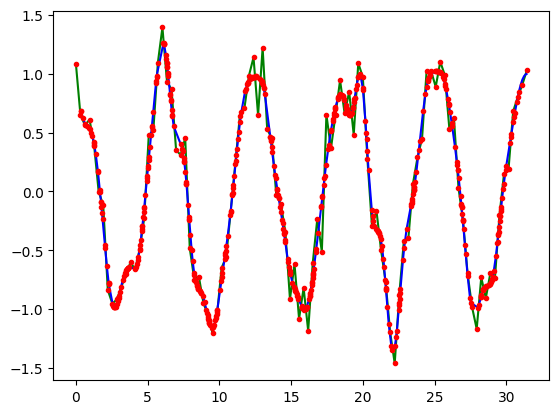

In [94]:
plt.plot(x,t, 'g')    # training set
plt.plot(x_,μ_t, 'b') # predicted set
xx = np.r_[x, x_]  # placing x-train and x-predict into the same array
tt = np.r_[t, μ_t.reshape(m,1)] # placing t-train and t-predict into the same array
plt.plot(xx[:-10], tt[:-10], '.r') # combined set


To conduct the prediction more efficiently we can use the Cholesky decomposition


$m(x_{N+1}) = \boldsymbol{k}^{T} \boldsymbol{(LL^T)}^{-1} \boldsymbol{t}$

$\sigma^2(x_{N+1}) = c - \boldsymbol{k}^{T} \boldsymbol{(LL^T)}^{-1} \boldsymbol{k}$
